### **UNIVERSIDADE FEDERAL DE ITAJUBÁ**
### **Instituto de Matemática e Computação**
### **Ciência da Computação**

--

### **XMCO09 - Ciência de Redes**

### **Tópico: 3. Modelos de Redes**

## **Atividade 3 (AT3)**

---

**Objetivo:** Este notebook visa apresentar os modelos clássicos de redes baseados em redes aleatórias e redes livre de escala, conhecer as principais características de cada modelo, além das principais medidas para a análise de suas propriedades. Para cada enunciado a seguir implemente os códigos de modo a atender o que se pede.

---

In [1]:
import sys
sys.path.insert(0, "..")

import math, random, statistics
import numpy as np
import matplotlib.pyplot as plt
import igraph as ig

from collections import Counter
from methods.similarity import common_aisles, common_items
from process.dataset import Problem
from process.graph import Graph

instance = input("Enter the instance name (e.g., 'instance_0001.txt'): ")
problem = Problem("../../dataset/" + instance)

In [25]:
# Reprodutibilidade
from prompt_toolkit import layout


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Funções auxiliares de plotagem
def plot_igraph_matplotlib(g, ax=None, layout_name="fr", vertex_size=6, edge_alpha=0.2):
    if ax is None:
        ax = plt.gca()
    layout = g.layout(layout_name)
    coords = np.array(layout.coords, dtype=float)

    # Desenha arestas
    edges = np.array(g.get_edgelist())
    if len(edges) > 0:
        for (u, v) in edges:
            x = [coords[u,0], coords[v,0]]
            y = [coords[u,1], coords[v,1]]
            ax.plot(x, y, linewidth=0.5, alpha=edge_alpha)

        # Desenha vértices
        ax.scatter(coords[:,0], coords[:,1], s=vertex_size, zorder=3)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect("equal", adjustable="datalim")

def poisson_pmf(k, lam):
    return math.exp(-lam) * (lam**k) / math.factorial(k)

def empirical_degree_hist(g):
    degs = g.degree()
    maxk = max(degs) if len(degs) else 0
    counts = np.bincount(degs, minlength=maxk+1)
    pk = counts / counts.sum() if counts.sum() > 0 else counts
    return np.arange(len(pk)), pk

def avg_path_length_sampled(g, samples=400):
    if g.vcount() == 0:
        return float("nan")
    
    sources = np.random.choice(g.vcount(), size=min(samples, g.vcount()), replace=False)
    total = 0
    count = 0

    # Usa BFS não ponderado
    for s in sources:
        dists = g.shortest_paths(s)[0]
        finites = [d for d in dists if d < float("inf") and d > 0]
        total += sum(finites)
        count += len(finites)

    return total / count if count else float("nan")

def lcc(g):
    comps = g.components()
    giant = comps.giant()
    return giant

def cayley_nodes_within_t(k, t):
    """
    Nº de nós alcançáveis em <= t passos a partir do nó central
    numa árvore de Cayley (grau k), ignorando o limite de profundidade P.
    Fórmula: 1 + k * ((k-1)^t - 1)/(k-2), para k != 2;
    e 2*t + 1 para k = 2 (linha).
    """
    if t < 0:
        return 0
    if k == 2:
        return 2*t + 1
    if k == 1:
        return t + 1
    return 1 + k * (( (k-1)**t - 1) / (k-2))

def cayley_shell_count(k, d):
    """
    Nº de nós exatamente na casca (distância) d a partir do centro.
    d=0 -> 1; d=1 -> k; d>=2 -> k*(k-1)^(d-1)
    """
    if d == 0: return 1
    if d == 1: return k
    return k * (k-1)**(d-1)

def solve_connectivity_threshold_N(p, Nmax=2000000):
    """
    Para um dado p (ER), aproxima N tal que p >= (ln N)/N (limiar de conectividade).
    Retorna o menor N que satisfaz a desigualdade (se encontrar).
    """
    for N in range(2, Nmax+1):
        if math.log(N)/N <= p:
            return N
    return None

def sample_powerlaw_degrees(N, gamma, kmin=1, kmax=None):
    """
    Amostra uma sequência de graus de lei de potência discreta truncada: P(k) ~ k^-gamma.
    Usa inversão de CDF contínua seguida de arredondamento e clamp em [kmin, kmax].
    Garante soma de graus par.
    """
    if kmax is None:
        kmax = N-1
    a = 1.0 - gamma
    def inv_cdf(u):
        return ((u*(kmax**a - kmin**a) + kmin**a))**(1.0/a)
    u = np.random.random(size=N)
    ks = np.clip(np.rint(inv_cdf(u)).astype(int), kmin, kmax)
    ks = np.minimum(ks, N-1)
    s = ks.sum()
    if s % 2 == 1:
        i = np.random.randint(0, N)
        if ks[i] < kmax:
            ks[i] += 1
        else:
            ks[i] -= 1
    return ks.tolist()

def multiedge_selfloop_percentages(g):
    """
    Percentuais de multiarestas e auto-loops em um grafo possivelmente multigrafo.
    Retorna (pct_multiedges, pct_selfloops) como porcentagens do total de arestas.
    """
    m = g.ecount()
    if m == 0:
        return 0.0, 0.0
    loops = sum(1 for e in g.es if e.tuple[0] == e.tuple[1])
    pairs = [tuple(sorted(e.tuple)) for e in g.es if e.tuple[0] != e.tuple[1]]
    c = Counter(pairs)
    excess = sum(cnt - 1 for cnt in c.values() if cnt > 1)
    pct_loops = 100.0 * loops / m
    pct_multi = 100.0 * excess / m
    return pct_multi, pct_loops

def degree_distribution(g):
    degs = np.array(g.degree())
    vals, counts = np.unique(degs, return_counts=True)
    pk = counts / counts.sum()
    return vals, pk

print("Pacotes OK. Funções auxiliares carregadas.")

Pacotes OK. Funções auxiliares carregadas.


## **1. Redes Aleatórias (Erdös-Réiny)**

**Q1.** Gere uma rede Erdös-Rényi com $N$ = 3.000 nós, conectados entre si com probabilidade $p = 10^{-3}$.

In [3]:
network_nodes_quantity = int(input("Enter the number of nodes for the network: "))
connection_probability = 1e-3  # Default connection probability for ER graph
graph_random_network_ER = ig.Graph.Erdos_Renyi(n=network_nodes_quantity, p=connection_probability, directed=False, loops=False)
print(f"Random ER graph created with {network_nodes_quantity} nodes and connection probability {connection_probability}, with {graph_random_network_ER.ecount()} edges.")

Random ER graph created with 3000 nodes and connection probability 0.001, with 4591 edges.


**Q2.** Qual o número esperado de links $\langle L \rangle$?

In [4]:
nodes = network_nodes_quantity; probability = connection_probability
L_exp = probability * nodes * (nodes - 1) / 2
print(f"⟨L⟩ esperado = probability * nodes*(nodes-1)/2 = {L_exp:.2f}")
print(f"Comparação: L real no grafo gerado = {graph_random_network_ER.ecount()}")

⟨L⟩ esperado = probability * nodes*(nodes-1)/2 = 4498.50
Comparação: L real no grafo gerado = 4591


**Q3.** Em qual regime a rede está?

In [5]:
k_mean = connection_probability * (network_nodes_quantity - 1)
regime = "subcrítico (⟨k⟩<1)"
if abs(k_mean - 1) < 1e-6:
    regime = "crítico (⟨k⟩≈1)"
elif k_mean > 1:
    regime = "supercrítico (⟨k⟩>1)"
print(f"⟨k⟩ = {k_mean:.3f} ⇒ regime {regime}.")
print(f"ln(N) ≈ {math.log(network_nodes_quantity):.2f} ⇒ rede provavelmente NÃO está totalmente conectada.")
giant = lcc(graph_random_network_ER)
frac_giant = giant.vcount() / network_nodes_quantity
print(f"Fração de nós no maior componente (observado): {frac_giant:.3f}")

⟨k⟩ = 2.999 ⇒ regime supercrítico (⟨k⟩>1).
ln(N) ≈ 8.01 ⇒ rede provavelmente NÃO está totalmente conectada.
Fração de nós no maior componente (observado): 0.940


**Q4.** Calcule a probabilidade $p_c$ para que a rede esteja no ponto crítico.

In [9]:
critical_point_probability = 1.0/(network_nodes_quantity - 1)
print(f"critical point probability ≈ 1/(N-1) = {critical_point_probability*100:.2f}%")

critical point probability ≈ 1/(N-1) = 0.03%


**Q5.** Dada a probabilidade de ligação $p = 10^{-3}$, calcule o número de nós $N$ para que a rede tenha apenas um componente.

In [10]:
nodes_unique_component = solve_connectivity_threshold_N(connection_probability)
print(f"Menor N com (ln N)/N ≤ {connection_probability} ≈ {nodes_unique_component} (aprox.)")

Menor N com (ln N)/N ≤ 0.001 ≈ 9119 (aprox.)


**Q6.** Calcule o grau médio $\langle k \rangle$ e a distância média $\langle d \rangle$ entre dois nós escolhidos aleatoriamente.

In [11]:
degree_mean = 2 * graph_random_network_ER.ecount() / graph_random_network_ER.vcount()
giant = lcc(graph_random_network_ER)
try:
    distance_mean = giant.average_path_length()
except Exception:
    distance_mean = avg_path_length_sampled(giant, samples=400)
print(f"Grau médio (observado) ⟨k⟩ = {degree_mean:.3f}")
print(f"Distância média (no maior componente) ⟨d⟩ ≈ {distance_mean:.3f}")

Grau médio (observado) ⟨k⟩ = 3.061
Distância média (no maior componente) ⟨d⟩ ≈ 7.145


**Q7.** Calcule a distribuição de graus $p_{k}$ desta rede (aproximada com uma distribuição de graus de Poisson).

λ (grau médio) ≈ 3.061
k= 0 p_emp=0.0513 p_pois~=0.0469
k= 1 p_emp=0.1347 p_pois~=0.1434
k= 2 p_emp=0.2113 p_pois~=0.2195
k= 3 p_emp=0.2397 p_pois~=0.2239
k= 4 p_emp=0.1680 p_pois~=0.1713
k= 5 p_emp=0.1060 p_pois~=0.1049
k= 6 p_emp=0.0543 p_pois~=0.0535
k= 7 p_emp=0.0250 p_pois~=0.0234
k= 8 p_emp=0.0063 p_pois~=0.0089
k= 9 p_emp=0.0027 p_pois~=0.0030


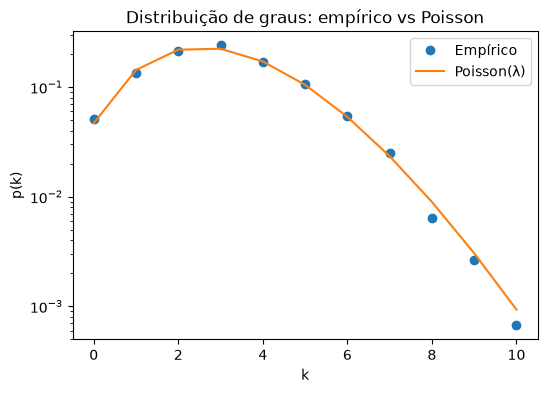

In [13]:
degrees = graph_random_network_ER.degree()
lam = np.mean(degrees)
k_vals, pk_emp = empirical_degree_hist(graph_random_network_ER)
pk_pois = np.array([poisson_pmf(k, lam) for k in k_vals])
print(f"λ (grau médio) ≈ {lam:.3f}")
for k in range(int(min(10, len(k_vals)))):
    print(f"k={k:2d} p_emp={pk_emp[k]:.4f} p_pois~={pk_pois[k]:.4f}")
plt.figure(figsize=(6,4))
plt.plot(k_vals, pk_emp, marker='o', linestyle='', label='Empírico')
plt.plot(k_vals, pk_pois, linewidth=1.5, label='Poisson(λ)')
plt.yscale('log')
plt.xlabel('k'); plt.ylabel('p(k)')
plt.title('Distribuição de graus: empírico vs Poisson')
plt.legend()
plt.show()

**Q8.** Com base no modelo $G(N, p)$ , gere três redes com $N$ = 500 nós e grau médio **(a)** $\langle k \rangle$ = 0,8 **(b)** $\langle k \rangle$ = 1 e (c) **(a)** $\langle k \rangle$ = 8. Visualize essas redes.

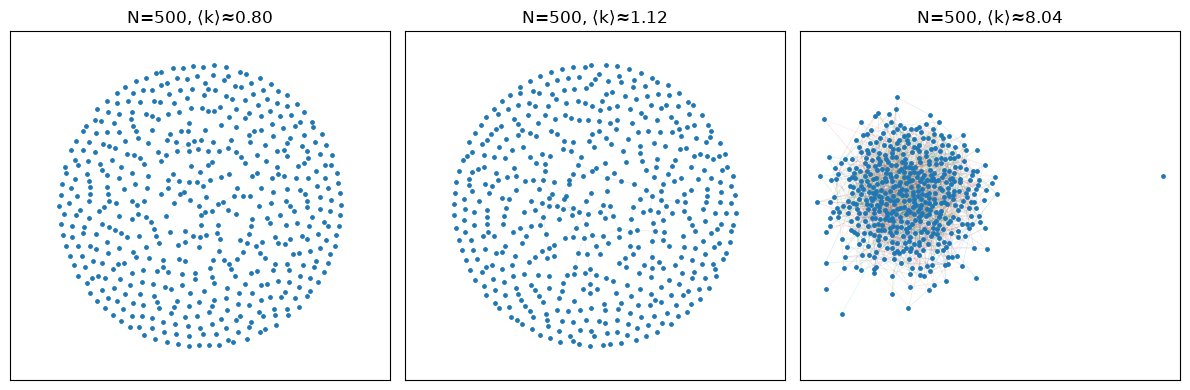

In [14]:
N = 500
targets = [0.8, 1.0, 8.0]
graphs = []
for kbar in targets:
    p = kbar / (N - 1)
    g = ig.Graph.Erdos_Renyi(n=N, p=p, directed=False, loops=False)
    graphs.append((kbar, g))
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, (kbar, g) in zip(axes, graphs):
    plot_igraph_matplotlib(g, ax=ax, layout_name="fr", vertex_size=6, edge_alpha=0.15)
    ax.set_title(f"N={N}, ⟨k⟩≈{2*g.ecount()/N:.2f}")
plt.tight_layout()
plt.show()

## **2. Árvore Cayley**

**Q9.** Uma árvore de Cayley (figura abaixo) é uma árvore simétrica, construída a partir de um nó central de grau $k$. Cada nó a uma distância $d$ do nó central tem grau $k$, até chegarmos aos nós a uma distância $P$ que têm grau 1 e são chamados de folhas (Ex. rede da figura $k$ = 3 e $P$ = 5). Calcule o número de nós alcançáveis em $t$ passos a partir do nó central.

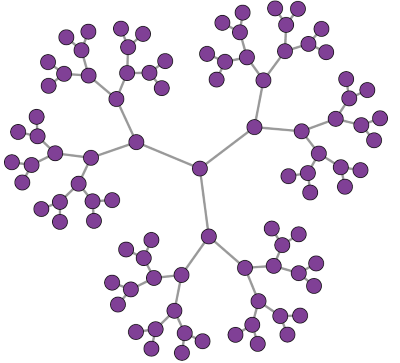

In [17]:
# Fórmula (k>=3): 1 + k * ((k-1)^t - 1)/(k-2)
# Para k=2 (linha): 2*t + 1
def cayley_nodes_within_t_demo(k, t):
    return cayley_nodes_within_t(k, t)
k, P = 3, 5
vals = [(t, int(cayley_nodes_within_t_demo(k,t))) for t in range(P+1)]
for t, n in vals:
    print(f"k={k}, t={t}: nós alcançáveis (≤ t) = {n}")

k=3, t=0: nós alcançáveis (≤ t) = 1
k=3, t=1: nós alcançáveis (≤ t) = 4
k=3, t=2: nós alcançáveis (≤ t) = 10
k=3, t=3: nós alcançáveis (≤ t) = 22
k=3, t=4: nós alcançáveis (≤ t) = 46
k=3, t=5: nós alcançáveis (≤ t) = 94


**Q10.** Calcule a distribuição de graus da rede.

In [18]:
def cayley_degree_distribution(k, P):
    center = 1
    internal_shells = sum(cayley_shell_count(k, d) for d in range(1, P))
    leaves = cayley_shell_count(k, P)
    n_total = center + internal_shells + leaves
    counts = {k: center + internal_shells, 1: leaves}
    pk = {deg: cnt / n_total for deg, cnt in counts.items()}
    return counts, pk, n_total
k, P = 3, 5
counts, pk, n_tot = cayley_degree_distribution(k, P)
print(f"k={k}, P={P}, N_total={n_tot}")
print("Contagens por grau:", counts)
print("Distribuição p(k):", {deg: f"{p:.4f}" for deg, p in pk.items()})

k=3, P=5, N_total=94
Contagens por grau: {3: 46, 1: 48}
Distribuição p(k): {3: '0.4894', 1: '0.5106'}


**Q11.** Calcule o diâmetro $d_{max}$.

In [19]:
def cayley_diameter(P): return 2*P
P = 5
print(f"P={P} ⇒ diâmetro d_max = {cayley_diameter(P)}")

P=5 ⇒ diâmetro d_max = 10


**Q12.** A rede exibe a propriedade de mundo pequeno?

⟨k⟩ (teórico, truncado) ≈ 2.452
⟨k_nn⟩ (teórico, não-correlacionado) = ⟨k^2⟩/⟨k⟩ ≈ 50.964
Comparação: ⟨k_nn⟩ ≥ ⟨k⟩; para γ<3, ⟨k^2⟩ cresce forte ⇒ vizinhos tendem a ter graus maiores que a média.


## **3. Redes Livre de Escala**

**Q13.** Calcule o grau médio dos vizinhos de um nó escolhido aleatoriamente em uma rede com $N$ = $10^4$ ; $\gamma$ = 2,3 ; $k_{min}$ = 1 e $k_{max}$ = 1.000. Compare o resultado com o grau médio da rede $\langle k \rangle$.

In [22]:
def truncated_powerlaw_moments(gamma, kmin, kmax):
    ks = np.arange(kmin, kmax+1)
    Z = np.sum(ks**(-gamma))
    pk = (ks**(-gamma)) / Z
    m1 = np.sum(ks * pk)
    m2 = np.sum((ks**2) * pk)
    return m1, m2
N = 10_000
gamma = 2.3
kmin = 1
kmax = 1000
k_mean, k2 = truncated_powerlaw_moments(gamma, kmin, kmax)
knn = k2 / k_mean
print(f"⟨k⟩ (teórico, truncado) ≈ {k_mean:.3f}")
print(f"⟨k_nn⟩ (teórico, não-correlacionado) = ⟨k^2⟩/⟨k⟩ ≈ {knn:.3f}")
print("Comparação: ⟨k_nn⟩ ≥ ⟨k⟩; para γ<3, ⟨k^2⟩ cresce forte ⇒ vizinhos tendem a ter graus maiores que a média.")

⟨k⟩ (teórico, truncado) ≈ 2.452
⟨k_nn⟩ (teórico, não-correlacionado) = ⟨k^2⟩/⟨k⟩ ≈ 50.964
Comparação: ⟨k_nn⟩ ≥ ⟨k⟩; para γ<3, ⟨k^2⟩ cresce forte ⇒ vizinhos tendem a ter graus maiores que a média.


**Q14.** Gere três redes de tamanho $N$ com uma distribuição de graus de lei de potência com expoente de grau $\gamma$. Gere as três redes com $\gamma$ = 2,2 e com $N$ = 103, $N$ = 104 e $N$ = 105 nós, respectivamente. Qual é a porcentagem de multi-links e selfloops em cada rede? Gere mais redes para plotar essa porcentagem em função de $N$. Faça o mesmo para redes com $\gamma$ = 3.

γ=2.2, N=1000: multiedges=11.65%, selfloops=1.91%
γ=2.2, N=2000: multiedges=5.63%, selfloops=0.62%
γ=2.2, N=5000: multiedges=4.54%, selfloops=0.27%
γ=2.2, N=10000: multiedges=3.14%, selfloops=0.19%
γ=2.2, N=20000: multiedges=3.28%, selfloops=0.12%
γ=2.2, N=50000: multiedges=0.97%, selfloops=0.03%
γ=3.0, N=1000: multiedges=0.22%, selfloops=0.11%
γ=3.0, N=2000: multiedges=0.00%, selfloops=0.10%
γ=3.0, N=5000: multiedges=0.18%, selfloops=0.06%
γ=3.0, N=10000: multiedges=0.07%, selfloops=0.03%
γ=3.0, N=20000: multiedges=0.00%, selfloops=0.01%
γ=3.0, N=50000: multiedges=0.01%, selfloops=0.00%


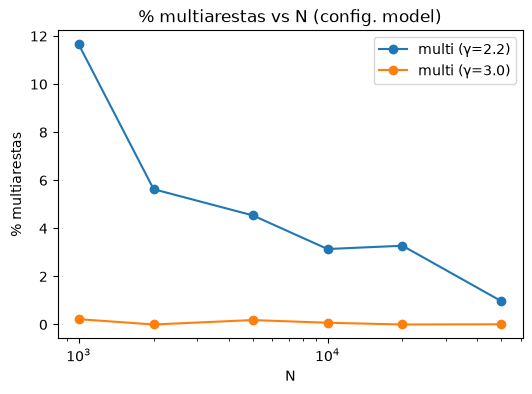

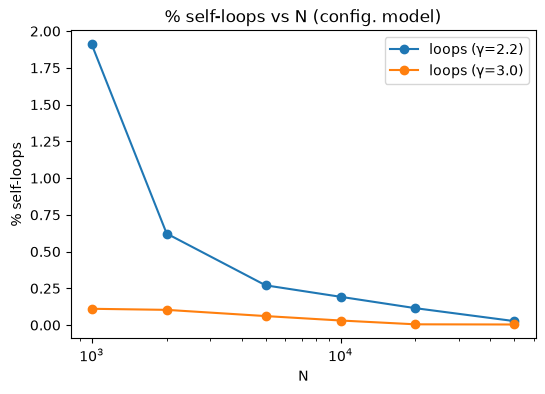

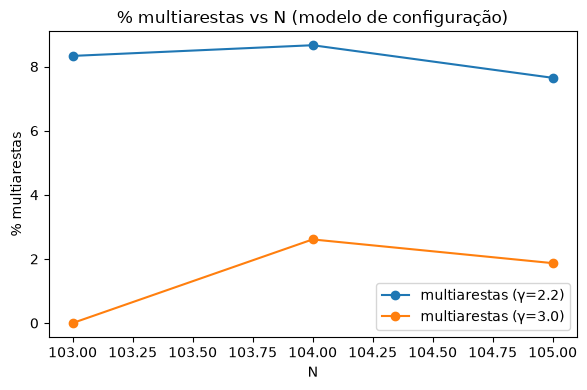

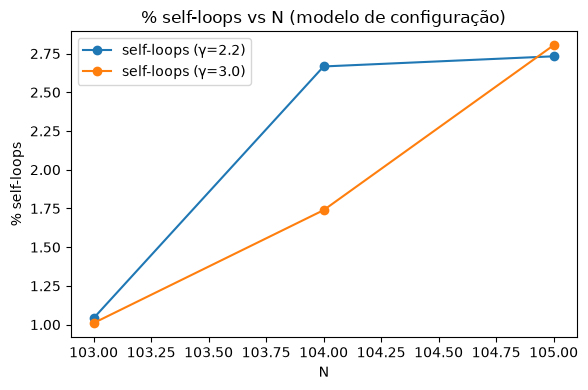

In [26]:
def one_run_percentages(N, gamma, kmin=1):
    kmax = min(1000, N-1)
    degs = sample_powerlaw_degrees(N, gamma, kmin=kmin, kmax=kmax)
    g = ig.Graph.Degree_Sequence(degs, method="configuration")
    return multiedge_selfloop_percentages(g)
Ns = [1000, 2000, 5000, 10000, 20000, 50000]
gammas = [2.2, 3.0]
results = {gamma: {"N": [], "pct_multi": [], "pct_loops": []} for gamma in gammas}

for gamma in gammas:
    for N in Ns:
        pct_multi, pct_loops = one_run_percentages(N, gamma)
        results[gamma]["N"].append(N)
        results[gamma]["pct_multi"].append(pct_multi)
        results[gamma]["pct_loops"].append(pct_loops)
        print(f"γ={gamma}, N={N}: multiedges={pct_multi:.2f}%, selfloops={pct_loops:.2f}%")
plt.figure(figsize=(6,4))

for gamma in gammas:
    plt.plot(results[gamma]["N"], results[gamma]["pct_multi"], marker='o', label=f"multi (γ={gamma})")
plt.xscale('log'); plt.xlabel("N"); plt.ylabel("% multiarestas")
plt.title("% multiarestas vs N (config. model)")
plt.legend(); plt.show()
plt.figure(figsize=(6,4))

for gamma in gammas:
    plt.plot(results[gamma]["N"], results[gamma]["pct_loops"], marker='o', label=f"loops (γ={gamma})")
plt.xscale('log'); plt.xlabel("N"); plt.ylabel("% self-loops")
plt.title("% self-loops vs N (config. model)")
plt.legend(); plt.show()

def one_run_percentages(N, gamma, kmin=1):
    kmax = min(1000, N - 1)
    degs = sample_powerlaw_degrees(N, gamma, kmin=kmin, kmax=kmax)
    if sum(degs) % 2 == 1:
        if degs[-1] < kmax:
            degs[-1] += 1
        elif degs[-1] > kmin:
            degs[-1] -= 1
        else:
            for i in range(len(degs)):
                if degs[i] < kmax:
                    degs[i] += 1
                    break
    g = ig.Graph.Degree_Sequence(degs, method="configuration")
    return multiedge_selfloop_percentages(g)

Ns = [103, 104, 105]
gammas = [2.2, 3.0]

results = {gamma: {"N": [], "pct_multi": [], "pct_loops": []} for gamma in gammas}

for gamma in gammas:
    for N in Ns:
        pct_multi, pct_loops = one_run_percentages(N, gamma)
        results[gamma]["N"].append(N)
        results[gamma]["pct_multi"].append(pct_multi)
        results[gamma]["pct_loops"].append(pct_loops)
plt.figure(figsize=(6,4))

for gamma in gammas:
    plt.plot(results[gamma]["N"], results[gamma]["pct_multi"], marker='o', label=f"multiarestas (γ={gamma})")
plt.xlabel("N")
plt.ylabel("% multiarestas")
plt.title("% multiarestas vs N (modelo de configuração)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
for gamma in gammas:
    plt.plot(results[gamma]["N"], results[gamma]["pct_loops"], marker='o', label=f"self-loops (γ={gamma})")
plt.xlabel("N")
plt.ylabel("% self-loops")
plt.title("% self-loops vs N (modelo de configuração)")
plt.legend()
plt.tight_layout()
plt.show()

**Q15.** Gere uma rede com $N$ = $10^4$ nós usando o modelo de Barabási-Albert com $m$ = 4. Use como condição inicial uma rede totalmente conectada com $m$ = 4 nós.

In [27]:
N_ba = 10000
m = 4
g0 = ig.Graph.Full(m)
try:
    g_ba = ig.Graph.Barabasi(n=N_ba, m=m, directed=False, start_from=g0, power=1.0)
except Exception:
    g_ba = g0.copy()
    urn = []
    for v in range(g_ba.vcount()):
        urn += [v] * g_ba.degree(v)
    for new_id in range(g_ba.vcount(), N_ba):
        g_ba.add_vertex()
        targets = set()
        while len(targets) < m:
            if len(urn) == 0:
                targets = set(range(m))
                break
            cand = random.choice(urn)
            if cand != new_id:
                targets.add(cand)
        for t in targets:
            g_ba.add_edge(new_id, t)
        deg_new = g_ba.degree(new_id)
        urn += [new_id] * deg_new
        for t in targets:
            urn += [t]
print(f"BA gerado: N={g_ba.vcount()}, L={g_ba.ecount()}, m≈{m}")

BA gerado: N=10000, L=39990, m≈4


**Q16.** Meça a distância média $\langle d \rangle$ e distribuição de graus em etapas intermediárias, ou seja, quando a rede tem $10^2$, $10^3$ e $10^4$ nós.

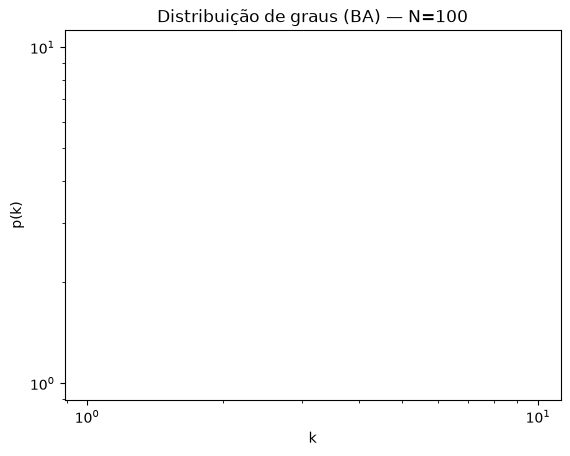

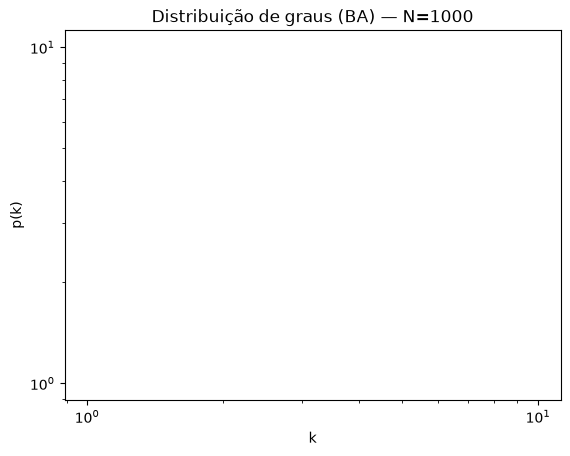

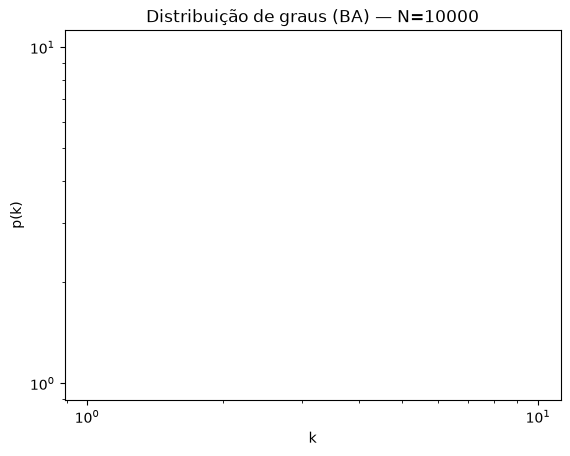

In [ ]:
sizes = [100, 1000, 10000]
ba_graphs = {}
for n in sizes:
    try:
        g = ig.Graph.Barabasi(n=n, m=4, directed=False, start_from=ig.Graph.Full(4), power=1.0)
    except Exception:
        if n <= 2000:
            g = ig.Graph.Barabasi(n=n, m=4, directed=False)
        else:
            g = g_ba
    ba_graphs[n] = g
for n, g in ba_graphs.items():
    try:
        d = g.average_path_length()
    except Exception:
        d = avg_path_length_sampled(g, samples=400)
        k_vals, pk = degree_distribution(g)
        print(f"N={n}: ⟨d⟩≈{d:.3f}, grau médio≈{2*g.ecount()/g.vcount():.2f}, máx grau={max(g.degree())}")
        plt.figure(figsize=(5,4))
        plt.plot(k_vals, pk, marker='o', linestyle='')
        plt.xscale('log'); plt.yscale('log')
        plt.xlabel('k'); plt.ylabel('p(k)')
        plt.title(f'Distribuição de graus (BA) — N={n}')
        plt.show()

**Q17.** Compare as distribuições nessas etapas intermediárias, plotando-as juntas.

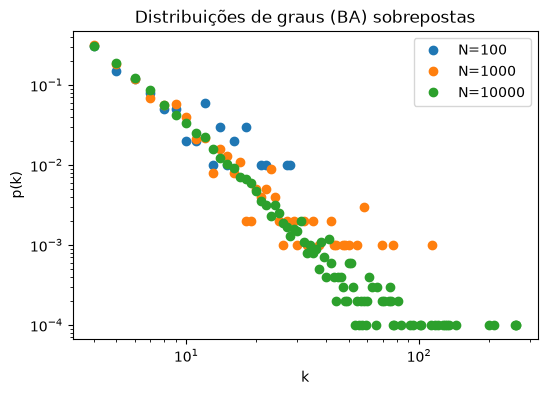

In [33]:
plt.figure(figsize=(6,4))
for n in [100, 1000, 10000]:
    g = ba_graphs[n]
    k_vals, pk = degree_distribution(g)
    plt.plot(k_vals, pk, marker='o', linestyle='', label=f"N={n}")
plt.xscale('log'); plt.yscale('log')
plt.xlabel('k'); plt.ylabel('p(k)')
plt.title('Distribuições de graus (BA) sobrepostas')
plt.legend(); plt.show()

**Q18.** Trace as distribuições cumulativas de graus em etapas intermediárias.

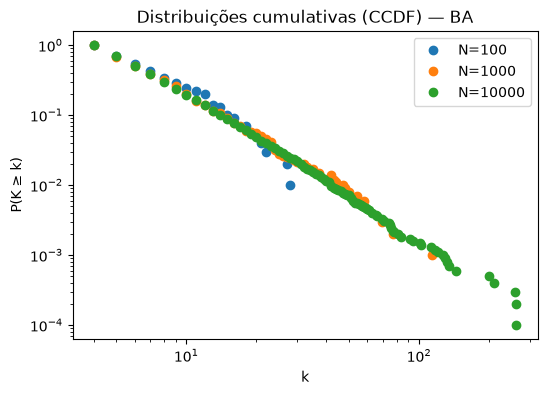

In [34]:
plt.figure(figsize=(6,4))
for n in [100, 1000, 10000]:
    g = ba_graphs[n]
    degs = np.array(g.degree())
    uniq = np.unique(degs)
    ccdf = [np.mean(degs >= k) for k in uniq]
    plt.plot(uniq, ccdf, marker='o', linestyle='', label=f"N={n}")
plt.xscale('log'); plt.yscale('log')
plt.xlabel('k'); plt.ylabel('P(K ≥ k)')
plt.title('Distribuições cumulativas (CCDF) — BA')
plt.legend(); plt.show()

**Q19.** Meça o coeficiente de agrupamento médio em função de $N$ .

N=100: C_médio ≈ 0.1732
N=300: C_médio ≈ 0.0605
N=1000: C_médio ≈ 0.0315
N=3000: C_médio ≈ 0.0140
N=10000: C_médio ≈ 0.0050


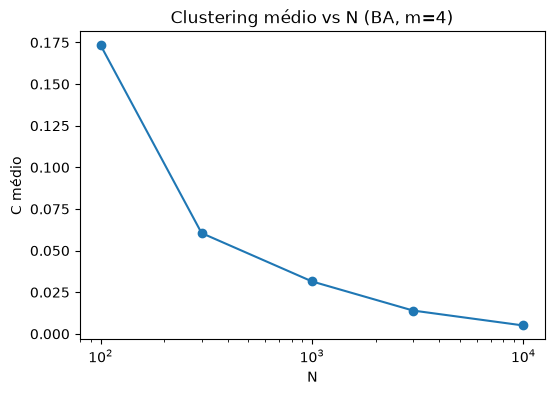

In [35]:
Ns = [100, 300, 1000, 3000, 10000]
C = []
for n in Ns:
    try:
        g = ig.Graph.Barabasi(n=n, m=4, directed=False, start_from=ig.Graph.Full(4), power=1.0)
    except Exception:
        g = ig.Graph.Barabasi(n=n, m=4, directed=False)
    c = g.transitivity_avglocal_undirected()
    C.append(c)
    print(f"N={n}: C_médio ≈ {c:.4f}")
plt.figure(figsize=(6,4))
plt.plot(Ns, C, marker='o')
plt.xscale('log')
plt.xlabel('N'); plt.ylabel('C médio')
plt.title('Clustering médio vs N (BA, m=4)')
plt.show()